In [9]:
import pandas as pd

orders = pd.read_csv("orders.csv")
drivers = pd.read_csv("drivers.csv")

print(orders.head())
print(drivers.head())

  order_id customer_zone  distance_km  order_value     status
0       O1         North            3           20    pending
1       O2         South           10           35    pending
2       O3         North            5           15  cancelled
3       O4       Central           20           40    pending
4       O5         South            8           25    pending
  driver_id driver_name customer_zone vehicle_type  max_orders  available
0        D1         Ali         North         bike           4          1
1        D2        Sara         South         bike           3          1
2        D3        John       Central          car           5          1
3        D4        Mina         North         bike           4          0
4        D5       Ahmed         South          car           5          1


In [10]:
matches = pd.merge(
    orders,
    drivers,
    on="customer_zone"
)

print(matches)

   order_id customer_zone  distance_km  order_value     status driver_id  \
0        O1         North            3           20    pending        D1   
1        O1         North            3           20    pending        D4   
2        O1         North            3           20    pending        D7   
3        O2         South           10           35    pending        D2   
4        O2         South           10           35    pending        D5   
5        O2         South           10           35    pending        D8   
6        O3         North            5           15  cancelled        D1   
7        O3         North            5           15  cancelled        D4   
8        O3         North            5           15  cancelled        D7   
9        O4       Central           20           40    pending        D3   
10       O4       Central           20           40    pending        D6   
11       O5         South            8           25    pending        D2   
12       O5 

In [11]:
matches = matches[
    [
        "order_id",
        "driver_id",
        "driver_name",
        "customer_zone",
        "distance_km",
        "order_value",
        "vehicle_type",
        "max_orders"
    ]
]

print(matches.head())

  order_id driver_id driver_name customer_zone  distance_km  order_value  \
0       O1        D1         Ali         North            3           20   
1       O1        D4        Mina         North            3           20   
2       O1        D7        Omar         North            3           20   
3       O2        D2        Sara         South           10           35   
4       O2        D5       Ahmed         South           10           35   

  vehicle_type  max_orders  
0         bike           4  
1         bike           4  
2          car           4  
3         bike           3  
4          car           5  


In [12]:
matches["priority_score"] = matches["order_value"] / matches["distance_km"]

print(matches.head())

  order_id driver_id driver_name customer_zone  distance_km  order_value  \
0       O1        D1         Ali         North            3           20   
1       O1        D4        Mina         North            3           20   
2       O1        D7        Omar         North            3           20   
3       O2        D2        Sara         South           10           35   
4       O2        D5       Ahmed         South           10           35   

  vehicle_type  max_orders  priority_score  
0         bike           4        6.666667  
1         bike           4        6.666667  
2          car           4        6.666667  
3         bike           3        3.500000  
4          car           5        3.500000  


In [13]:
matches = matches.sort_values(
    by="priority_score",
    ascending=False
)

print(matches.head(10))

   order_id driver_id driver_name customer_zone  distance_km  order_value  \
16       O6        D7        Omar         North            2           18   
15       O6        D4        Mina         North            2           18   
14       O6        D1         Ali         North            2           18   
1        O1        D4        Mina         North            3           20   
0        O1        D1         Ali         North            3           20   
2        O1        D7        Omar         North            3           20   
19       O8        D2        Sara         South            4           22   
21       O8        D8        Nora         South            4           22   
20       O8        D5       Ahmed         South            4           22   
3        O2        D2        Sara         South           10           35   

   vehicle_type  max_orders  priority_score  
16          car           4        9.000000  
15         bike           4        9.000000  
14         bik

In [14]:
matches.to_csv("driver_order_matches.csv", index=False)

In [15]:
orders_per_zone = orders.groupby("customer_zone")["order_id"].count()

print(orders_per_zone)

customer_zone
Central    3
North      4
South      3
Name: order_id, dtype: int64


In [16]:
drivers_per_zone = drivers.groupby("customer_zone")["driver_id"].count()

print(drivers_per_zone)

customer_zone
Central    2
North      3
South      3
Name: driver_id, dtype: int64


In [17]:
zone_summary = pd.DataFrame({
    "total_orders": orders_per_zone,
    "total_drivers": drivers_per_zone
})

print(zone_summary)

               total_orders  total_drivers
customer_zone                             
Central                   3              2
North                     4              3
South                     3              3


In [18]:
zone_summary["orders_per_driver"] = (
    zone_summary["total_orders"] / zone_summary["total_drivers"]
)

print(zone_summary)

               total_orders  total_drivers  orders_per_driver
customer_zone                                                
Central                   3              2           1.500000
North                     4              3           1.333333
South                     3              3           1.000000


In [19]:
zone_summary.to_csv("zone_scheduling_summary.csv")

In [20]:
drivers.groupby("customer_zone")["max_orders"].sum()

,max_orders
customer_zone,
Central,8
North,12
South,10


In [21]:
capacity = drivers.groupby(
    "customer_zone"
)["max_orders"].sum()

demand = orders.groupby(
    "customer_zone"
)["order_id"].count()

comparison = pd.DataFrame({
    "demand": demand,
    "capacity": capacity
})

comparison["slack"] = (
    comparison["capacity"] -
    comparison["demand"]
)

print(comparison)

               demand  capacity  slack
customer_zone                         
Central             3         8      5
North               4        12      8
South               3        10      7


In [22]:
!pip install ortools

In [23]:
import pandas as pd
from ortools.sat.python import cp_model

In [24]:
model = cp_model.CpModel()

In [25]:
x = {}
for d in drivers["driver_id"]:
    for o in orders["order_id"]:
        x[d, o] = model.NewBoolVar(f"x_{d}_{o}")

In [26]:
for o in orders["order_id"]:
    model.Add(
        sum(x[d, o] for d in drivers["driver_id"]) == 1
    )

In [27]:
for _, driver in drivers.iterrows():
    d = driver["driver_id"]
    max_orders = driver["max_orders"]

    model.Add(
        sum(x[d, o] for o in orders["order_id"]) <= max_orders
    )

In [28]:
distance = dict(zip(orders["order_id"], orders["distance_km"]))

model.Minimize(
    sum(
        x[d, o] * distance[o]
        for d in drivers["driver_id"]
        for o in orders["order_id"]
    )
)

In [29]:
solver = cp_model.CpSolver()
status = solver.Solve(model)

In [30]:
if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
    for d in drivers["driver_id"]:
        assigned_orders = []
        for o in orders["order_id"]:
            if solver.Value(x[d, o]) == 1:
                assigned_orders.append(o)

        print(d, ":", assigned_orders)
else:
    print("No solution found")

D1 : []
D2 : ['O5']
D3 : ['O1', 'O6']
D4 : []
D5 : ['O3', 'O8']
D6 : ['O4', 'O7', 'O9']
D7 : []
D8 : ['O2', 'O10']


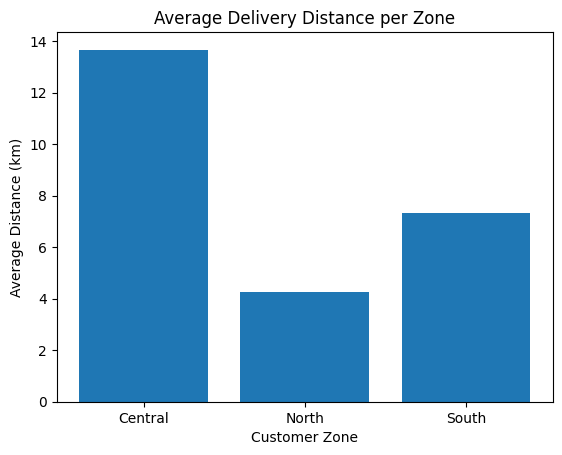

In [31]:
import matplotlib.pyplot as plt
avg_distance = orders.groupby("customer_zone")["distance_km"].mean()

plt.figure()
plt.bar(avg_distance.index, avg_distance.values)
plt.title("Average Delivery Distance per Zone")
plt.xlabel("Customer Zone")
plt.ylabel("Average Distance (km)")
plt.show()

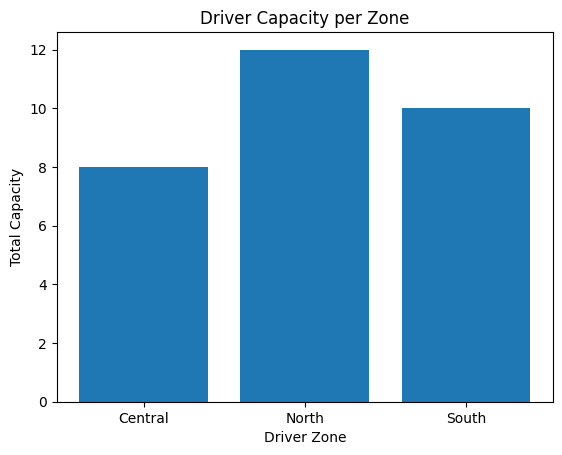

In [32]:
capacity_per_zone = drivers.groupby("customer_zone")["max_orders"].sum()

plt.figure()
plt.bar(capacity_per_zone.index, capacity_per_zone.values)
plt.title("Driver Capacity per Zone")
plt.xlabel("Driver Zone")
plt.ylabel("Total Capacity")
plt.show()
